In [1]:
import pandas as pd

# NBA Daten von basketball-reference.com
saisons = ["2022-23", "2023-24", "2024-25"]
alle_spiele = []

for saison in saisons:
    jahr = saison.split("-")[0]
    url = f"https://www.basketball-reference.com/leagues/NBA_{int(jahr)+1}_games.html"
    
    try:
        tabellen = pd.read_html(url)
        df = tabellen[0]
        df["Saison"] = saison
        alle_spiele.append(df)
        print(f"✅ Saison {saison}: {len(df)} Spiele geladen")
    except Exception as e:
        print(f"❌ Saison {saison}: {e}")

daten_nba = pd.concat(alle_spiele, ignore_index=True)
print(f"\nGesamt: {len(daten_nba)} Spiele")
print(f"Spalten: {daten_nba.columns.tolist()}")
daten_nba.head()

❌ Saison 2022-23: HTTP Error 403: Forbidden
❌ Saison 2023-24: HTTP Error 403: Forbidden
❌ Saison 2024-25: HTTP Error 403: Forbidden


ValueError: No objects to concatenate

In [2]:
!curl -L -o ~/Downloads/nba-games.zip \
  https://www.kaggle.com/api/v1/datasets/download/nathanlauga/nba-games

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 21.2M  100 21.2M    0     0  4702k      0  0:00:04  0:00:04 --:--:-- 6318k


In [3]:
import zipfile
import os

# Zip entpacken
with zipfile.ZipFile(os.path.expanduser("~/Downloads/nba-games.zip"), "r") as zip_ref:
    zip_ref.extractall(os.path.expanduser("~/Downloads/nba_daten"))

# Welche Dateien sind drin?
dateien = os.listdir(os.path.expanduser("~/Downloads/nba_daten"))
print("Enthaltene Dateien:")
for datei in dateien:
    print(f"  {datei}")

Enthaltene Dateien:
  teams.csv
  players.csv
  games.csv
  ranking.csv
  games_details.csv


In [4]:
import pandas as pd
import os

pfad = os.path.expanduser("~/Downloads/nba_daten")

# Wichtigste Dateien laden
games = pd.read_csv(f"{pfad}/games.csv")
ranking = pd.read_csv(f"{pfad}/ranking.csv")

print("=== GAMES ===")
print(f"Spiele: {len(games)}")
print(f"Spalten: {games.columns.tolist()}")
print(games.head(3))

print("\n=== RANKING ===")
print(f"Einträge: {len(ranking)}")
print(f"Spalten: {ranking.columns.tolist()}")
print(ranking.head(3))

=== GAMES ===
Spiele: 26651
Spalten: ['GAME_DATE_EST', 'GAME_ID', 'GAME_STATUS_TEXT', 'HOME_TEAM_ID', 'VISITOR_TEAM_ID', 'SEASON', 'TEAM_ID_home', 'PTS_home', 'FG_PCT_home', 'FT_PCT_home', 'FG3_PCT_home', 'AST_home', 'REB_home', 'TEAM_ID_away', 'PTS_away', 'FG_PCT_away', 'FT_PCT_away', 'FG3_PCT_away', 'AST_away', 'REB_away', 'HOME_TEAM_WINS']
  GAME_DATE_EST   GAME_ID GAME_STATUS_TEXT  HOME_TEAM_ID  VISITOR_TEAM_ID  \
0    2022-12-22  22200477            Final    1610612740       1610612759   
1    2022-12-22  22200478            Final    1610612762       1610612764   
2    2022-12-21  22200466            Final    1610612739       1610612749   

   SEASON  TEAM_ID_home  PTS_home  FG_PCT_home  FT_PCT_home  ...  AST_home  \
0    2022    1610612740     126.0        0.484        0.926  ...      25.0   
1    2022    1610612762     120.0        0.488        0.952  ...      16.0   
2    2022    1610612739     114.0        0.482        0.786  ...      22.0   

   REB_home  TEAM_ID_away  PTS_aw

In [5]:
# Nur letzte 3 Saisons
daten_nba = games[games["SEASON"].isin([2022, 2023, 2024])].copy()

# Datum formatieren
daten_nba["GAME_DATE_EST"] = pd.to_datetime(daten_nba["GAME_DATE_EST"])

# Fehlende Werte prüfen
print(f"Spiele: {len(daten_nba)}")
print(f"\nFehlende Werte:")
print(daten_nba.isnull().sum())

# Nach Datum sortieren
daten_nba = daten_nba.sort_values("GAME_DATE_EST").reset_index(drop=True)
daten_nba.head()

Spiele: 542

Fehlende Werte:
GAME_DATE_EST       0
GAME_ID             0
GAME_STATUS_TEXT    0
HOME_TEAM_ID        0
VISITOR_TEAM_ID     0
SEASON              0
TEAM_ID_home        0
PTS_home            0
FG_PCT_home         0
FT_PCT_home         0
FG3_PCT_home        0
AST_home            0
REB_home            0
TEAM_ID_away        0
PTS_away            0
FG_PCT_away         0
FT_PCT_away         0
FG3_PCT_away        0
AST_away            0
REB_away            0
HOME_TEAM_WINS      0
dtype: int64


,GAME_DATE_EST,GAME_ID,GAME_STATUS_TEXT,HOME_TEAM_ID,VISITOR_TEAM_ID,SEASON,TEAM_ID_home,PTS_home,FG_PCT_home,FT_PCT_home,...,AST_home,REB_home,TEAM_ID_away,PTS_away,FG_PCT_away,FT_PCT_away,FG3_PCT_away,AST_away,REB_away,HOME_TEAM_WINS
0,2022-09-30,12200001,Final,1610612764,1610612744,2022,1610612764,87.0,0.369,0.633,...,20.0,44.0,1610612744,96.0,0.367,0.775,0.269,18.0,62.0,0
1,2022-10-01,12200003,Final,1610612749,1610612763,2022,1610612749,102.0,0.430,0.714,...,22.0,50.0,1610612763,107.0,0.494,0.724,0.357,25.0,41.0,0
2,2022-10-02,12200006,Final,1610612761,1610612762,2022,1610612761,114.0,0.483,0.667,...,20.0,61.0,1610612762,82.0,0.323,0.588,0.250,21.0,46.0,1
3,2022-10-02,12200005,Final,1610612738,1610612766,2022,1610612738,134.0,0.571,0.800,...,41.0,56.0,1610612766,93.0,0.347,0.643,0.152,13.0,43.0,1
4,2022-10-02,12200004,Final,1610612744,1610612764,2022,1610612744,104.0,0.458,0.667,...,29.0,47.0,1610612764,95.0,0.353,0.900,0.242,23.0,46.0,1


In [6]:
# Form-Features für NBA berechnen
# Wir nutzen die letzten 5 Spiele jedes Teams

daten_nba["HomeWinRate"] = 0.0      # Siegquote Heimteam letzte 5 Spiele
daten_nba["AwayWinRate"] = 0.0      # Siegquote Auswärtsteam letzte 5 Spiele
daten_nba["HomePtsScored"] = 0.0    # Durchschnitt Punkte geschossen
daten_nba["HomePtsConceded"] = 0.0  # Durchschnitt Punkte kassiert
daten_nba["AwayPtsScored"] = 0.0
daten_nba["AwayPtsConceded"] = 0.0

for i, row in daten_nba.iterrows():
    for team_id, prefix in [(row["HOME_TEAM_ID"], "Home"), (row["VISITOR_TEAM_ID"], "Away")]:
        
        # Vergangene Spiele dieses Teams
        vergangene = daten_nba[
            ((daten_nba["HOME_TEAM_ID"] == team_id) | (daten_nba["VISITOR_TEAM_ID"] == team_id)) &
            (daten_nba["GAME_DATE_EST"] < row["GAME_DATE_EST"])
        ].tail(5)
        
        if len(vergangene) < 3:
            continue
        
        siege = 0
        pts_scored = []
        pts_conceded = []
        
        for _, spiel in vergangene.iterrows():
            if spiel["HOME_TEAM_ID"] == team_id:
                pts_scored.append(spiel["PTS_home"])
                pts_conceded.append(spiel["PTS_away"])
                if spiel["HOME_TEAM_WINS"] == 1:
                    siege += 1
            else:
                pts_scored.append(spiel["PTS_away"])
                pts_conceded.append(spiel["PTS_home"])
                if spiel["HOME_TEAM_WINS"] == 0:
                    siege += 1
        
        daten_nba.at[i, f"{prefix}WinRate"] = siege / len(vergangene)
        daten_nba.at[i, f"{prefix}PtsScored"] = sum(pts_scored) / len(pts_scored)
        daten_nba.at[i, f"{prefix}PtsConceded"] = sum(pts_conceded) / len(pts_conceded)

# Spiele ohne Features entfernen
daten_nba = daten_nba[daten_nba["HomeWinRate"] > 0].reset_index(drop=True)

print(f"Spiele mit vollständigen Features: {len(daten_nba)}")

Spiele mit vollständigen Features: 472


In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

features_nba = [
    "HomeWinRate", "AwayWinRate",
    "HomePtsScored", "HomePtsConceded",
    "AwayPtsScored", "AwayPtsConceded"
]

# Zeitbasierter Split – 80% Training, 20% Test
split = int(len(daten_nba) * 0.8)

X_train = daten_nba[features_nba].iloc[:split]
y_train = daten_nba["HOME_TEAM_WINS"].iloc[:split]
X_test = daten_nba[features_nba].iloc[split:]
y_test = daten_nba["HOME_TEAM_WINS"].iloc[split:]

modell_nba = LogisticRegression(max_iter=1000)
modell_nba.fit(X_train, y_train)

vorhersagen = modell_nba.predict(X_test)
genauigkeit = accuracy_score(y_test, vorhersagen)

print(f"Trainingsspiele: {len(X_train)}")
print(f"Testspiele:      {len(X_test)}")
print(f"\nGenauigkeit NBA: {genauigkeit:.1%}")
print(f"Zum Vergleich:")
print(f"  Zufälliges Raten: 50.0% (nur 2 Ausgänge!)")
print(f"  Bundesliga:       55.0%")

Trainingsspiele: 377
Testspiele:      95

Genauigkeit NBA: 58.9%
Zum Vergleich:
  Zufälliges Raten: 50.0% (nur 2 Ausgänge!)
  Bundesliga:       55.0%


In [8]:
# Erweiterte Features mit In-Game Stats der letzten Spiele
daten_nba["HomeFGPct"] = 0.0    # Feldwurfquote
daten_nba["AwayFGPct"] = 0.0
daten_nba["HomeAST"] = 0.0     # Assists
daten_nba["AwayAST"] = 0.0
daten_nba["HomeREB"] = 0.0     # Rebounds
daten_nba["AwayREB"] = 0.0

for i, row in daten_nba.iterrows():
    for team_id, prefix in [(row["HOME_TEAM_ID"], "Home"), (row["VISITOR_TEAM_ID"], "Away")]:
        
        vergangene = daten_nba[
            ((daten_nba["HOME_TEAM_ID"] == team_id) | (daten_nba["VISITOR_TEAM_ID"] == team_id)) &
            (daten_nba["GAME_DATE_EST"] < row["GAME_DATE_EST"])
        ].tail(5)
        
        if len(vergangene) < 3:
            continue
        
        fg_pct = []
        ast = []
        reb = []
        
        for _, spiel in vergangene.iterrows():
            if spiel["HOME_TEAM_ID"] == team_id:
                fg_pct.append(spiel["FG_PCT_home"])
                ast.append(spiel["AST_home"])
                reb.append(spiel["REB_home"])
            else:
                fg_pct.append(spiel["FG_PCT_away"])
                ast.append(spiel["AST_away"])
                reb.append(spiel["REB_away"])
        
        daten_nba.at[i, f"{prefix}FGPct"] = sum(fg_pct) / len(fg_pct)
        daten_nba.at[i, f"{prefix}AST"] = sum(ast) / len(ast)
        daten_nba.at[i, f"{prefix}REB"] = sum(reb) / len(reb)

# Erweitertes Modell
features_nba_v2 = [
    "HomeWinRate", "AwayWinRate",
    "HomePtsScored", "HomePtsConceded",
    "AwayPtsScored", "AwayPtsConceded",
    "HomeFGPct", "AwayFGPct",
    "HomeAST", "AwayAST",
    "HomeREB", "AwayREB"
]

X_train = daten_nba[features_nba_v2].iloc[:split]
y_train = daten_nba["HOME_TEAM_WINS"].iloc[:split]
X_test = daten_nba[features_nba_v2].iloc[split:]
y_test = daten_nba["HOME_TEAM_WINS"].iloc[split:]

modell_nba_v2 = LogisticRegression(max_iter=1000)
modell_nba_v2.fit(X_train, y_train)

vorhersagen_v2 = modell_nba_v2.predict(X_test)
genauigkeit_v2 = accuracy_score(y_test, vorhersagen_v2)

print(f"NBA v1 (basis):    58.9%")
print(f"NBA v2 (erweitert): {genauigkeit_v2:.1%}")


NBA v1 (basis):    58.9%
NBA v2 (erweitert): 62.1%


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [9]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Pipeline mit Scaling um Warnung zu beheben
pipeline_nba = Pipeline([
    ("scaler", StandardScaler()),
    ("modell", LogisticRegression(max_iter=2000))
])

pipeline_nba.fit(X_train, y_train)
vorhersagen_v3 = pipeline_nba.predict(X_test)
genauigkeit_v3 = accuracy_score(y_test, vorhersagen_v3)

print(f"NBA v1 (basis):         58.9%")
print(f"NBA v2 (erweitert):     62.1%")
print(f"NBA v3 (mit Scaling):   {genauigkeit_v3:.1%}")
print(f"\nZum Vergleich:")
print(f"  Bundesliga bestes:    60.0%")
print(f"  Zufälliges Raten NBA: 50.0%")

NBA v1 (basis):         58.9%
NBA v2 (erweitert):     62.1%
NBA v3 (mit Scaling):   58.9%

Zum Vergleich:
  Bundesliga bestes:    60.0%
  Zufälliges Raten NBA: 50.0%


In [10]:
# Elo Rating für NBA berechnen
# Wir starten nochmal mit den Originaldaten und fügen Elo hinzu

daten_nba["HomeElo"] = 0.0
daten_nba["AwayElo"] = 0.0
daten_nba["EloDiff"] = 0.0

elo = {}

for i, row in daten_nba.iterrows():
    home = row["HOME_TEAM_ID"]
    away = row["VISITOR_TEAM_ID"]
    
    if home not in elo: elo[home] = 1500
    if away not in elo: elo[away] = 1500
    
    # Elo VOR dem Spiel speichern
    daten_nba.at[i, "HomeElo"] = elo[home]
    daten_nba.at[i, "AwayElo"] = elo[away]
    daten_nba.at[i, "EloDiff"] = elo[home] - elo[away]
    
    # Erwartete Wahrscheinlichkeit
    erwartung_home = 1 / (1 + 10 ** ((elo[away] - elo[home]) / 400))
    erwartung_away = 1 - erwartung_home
    
    # Ergebnis
    if row["HOME_TEAM_WINS"] == 1:
        ergebnis_home, ergebnis_away = 1, 0
    else:
        ergebnis_home, ergebnis_away = 0, 1
    
    # Elo aktualisieren
    elo[home] += 32 * (ergebnis_home - erwartung_home)
    elo[away] += 32 * (ergebnis_away - erwartung_away)

# Aktuelles Elo Ranking
print("Top 10 NBA Teams aktuell:")
ranking_nba = pd.DataFrame(
    list(elo.items()),
    columns=["TeamID", "Elo"]
).sort_values("Elo", ascending=False)

# Teams Datei laden für Namen
teams = pd.read_csv(os.path.expanduser("~/Downloads/nba_daten/teams.csv"))
ranking_nba = ranking_nba.merge(teams[["TEAM_ID", "NICKNAME"]], 
                                 left_on="TeamID", right_on="TEAM_ID", how="left")
print(ranking_nba[["NICKNAME", "Elo"]].head(10).to_string(index=False))

Top 10 NBA Teams aktuell:
 NICKNAME         Elo
     Nets 1617.033547
    Bucks 1598.015460
Cavaliers 1591.730028
Grizzlies 1590.753119
  Nuggets 1576.716058
    76ers 1574.060700
  Celtics 1563.079538
   Knicks 1557.807948
 Clippers 1555.925995
    Kings 1548.422144


In [11]:
features_nba_elo = [
    "HomeWinRate", "AwayWinRate",
    "HomePtsScored", "HomePtsConceded",
    "AwayPtsScored", "AwayPtsConceded",
    "HomeFGPct", "AwayFGPct",
    "HomeAST", "AwayAST",
    "HomeREB", "AwayREB",
    "HomeElo", "AwayElo", "EloDiff"  # NEU
]

X_train = daten_nba[features_nba_elo].iloc[:split]
y_train = daten_nba["HOME_TEAM_WINS"].iloc[:split]
X_test = daten_nba[features_nba_elo].iloc[split:]
y_test = daten_nba["HOME_TEAM_WINS"].iloc[split:]

modell_nba_elo = LogisticRegression(max_iter=2000)
modell_nba_elo.fit(X_train, y_train)

vorhersagen_elo = modell_nba_elo.predict(X_test)
genauigkeit_elo = accuracy_score(y_test, vorhersagen_elo)

print(f"NBA v2 (ohne Elo): 62.1%")
print(f"NBA v3 (mit Elo):  {genauigkeit_elo:.1%}")

NBA v2 (ohne Elo): 62.1%
NBA v3 (mit Elo):  63.2%


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [12]:
!curl -L -o ~/Downloads/nba-odds.zip \
  https://www.kaggle.com/api/v1/datasets/download/christophertreasure/nba-odds-data

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  551k  100  551k    0     0   437k      0  0:00:01  0:00:01 --:--:--  802k


In [13]:
import zipfile
import os

with zipfile.ZipFile(os.path.expanduser("~/Downloads/nba-odds.zip"), "r") as zip_ref:
    zip_ref.extractall(os.path.expanduser("~/Downloads/nba_odds"))

dateien = os.listdir(os.path.expanduser("~/Downloads/nba_odds"))
print("Enthaltene Dateien:")
for datei in dateien:
    print(f"  {datei}")

Enthaltene Dateien:
  oddsData.csv


In [14]:
odds = pd.read_csv(os.path.expanduser("~/Downloads/nba_odds/oddsData.csv"))

print(f"Einträge: {len(odds)}")
print(f"Spalten: {odds.columns.tolist()}")
print(odds.head(3))

Einträge: 37104
Spalten: ['date', 'season', 'team', 'home/visitor', 'opponent', 'score', 'opponentScore', 'moneyLine', 'opponentMoneyLine', 'total', 'spread', 'secondHalfTotal']
         date  season       team home/visitor      opponent  score  \
0  2007-10-30    2008       Utah            @  Golden State    117   
1  2007-10-30    2008  LA Lakers           vs       Houston     93   
2  2007-10-30    2008    Houston            @     LA Lakers     95   

   opponentScore  moneyLine  opponentMoneyLine  total  spread  secondHalfTotal  
0             96      100.0             -120.0  212.0     1.0            105.5  
1             95      190.0             -230.0  199.0     5.0             99.0  
2             93     -230.0              190.0  199.0    -5.0             99.0  


In [15]:
print("Verfügbare Saisons:")
print(odds["season"].value_counts().sort_index().tail(10))
print(f"\nFormat Beispiel:")
print(odds[odds["season"] == 2024].head(3))

Verfügbare Saisons:
season
2014    2460
2015    2460
2016    2460
2017    2460
2018    2460
2019    2460
2020    2118
2021    2160
2022    2460
2023    1328
Name: count, dtype: int64

Format Beispiel:
Empty DataFrame
Columns: [date, season, team, home/visitor, opponent, score, opponentScore, moneyLine, opponentMoneyLine, total, spread, secondHalfTotal]
Index: []


In [16]:
# Nur vollständige Saisons nehmen
odds_filtered = odds[odds["season"].isin([2022, 2023])].copy()

# Nur Heimspiele (vs = home, @ = away)
odds_home = odds_filtered[odds_filtered["home/visitor"] == "vs"].copy()

print(f"Heimspiele mit Quoten: {len(odds_home)}")
print(f"\nBeispiel:")
print(odds_home[["date", "season", "team", "opponent", "moneyLine", "opponentMoneyLine"]].head(5))

Heimspiele mit Quoten: 1894

Beispiel:
             date  season       team      opponent  moneyLine  \
33316  2021-10-19    2022  Milwaukee      Brooklyn     -125.0   
33317  2021-10-19    2022  LA Lakers  Golden State     -160.0   
33320  2021-10-20    2022   New York        Boston     -140.0   
33322  2021-10-20    2022    Detroit       Chicago      190.0   
33323  2021-10-20    2022    Memphis     Cleveland     -280.0   

       opponentMoneyLine  
33316              105.0  
33317              140.0  
33320              120.0  
33322             -220.0  
33323              240.0  


In [17]:
def moneyline_zu_wahrscheinlichkeit(ml):
    if ml < 0:
        return abs(ml) / (abs(ml) + 100)
    else:
        return 100 / (ml + 100)

# Wahrscheinlichkeiten berechnen
odds_home["ProbHome"] = odds_home["moneyLine"].apply(moneyline_zu_wahrscheinlichkeit)
odds_home["ProbAway"] = odds_home["opponentMoneyLine"].apply(moneyline_zu_wahrscheinlichkeit)

# Normalisieren
gesamt = odds_home["ProbHome"] + odds_home["ProbAway"]
odds_home["ProbHome"] /= gesamt
odds_home["ProbAway"] /= gesamt

# Datum formatieren
odds_home["date"] = pd.to_datetime(odds_home["date"])

print("Beispiel Wahrscheinlichkeiten:")
print(odds_home[["date", "team", "opponent", "ProbHome", "ProbAway"]].head(5))

Beispiel Wahrscheinlichkeiten:
            date       team      opponent  ProbHome  ProbAway
33316 2021-10-19  Milwaukee      Brooklyn  0.532468  0.467532
33317 2021-10-19  LA Lakers  Golden State  0.596273  0.403727
33320 2021-10-20   New York        Boston  0.562044  0.437956
33322 2021-10-20    Detroit       Chicago  0.334029  0.665971
33323 2021-10-20    Memphis     Cleveland  0.714715  0.285285


In [18]:
# Teams Datei für Mapping laden
teams = pd.read_csv(os.path.expanduser("~/Downloads/nba_daten/teams.csv"))
print(teams[["TEAM_ID", "NICKNAME", "CITY"]].head(10).to_string())

      TEAM_ID   NICKNAME         CITY
0  1610612737      Hawks      Atlanta
1  1610612738    Celtics       Boston
2  1610612740   Pelicans  New Orleans
3  1610612741      Bulls      Chicago
4  1610612742  Mavericks       Dallas
5  1610612743    Nuggets       Denver
6  1610612745    Rockets      Houston
7  1610612746   Clippers  Los Angeles
8  1610612747     Lakers  Los Angeles
9  1610612748       Heat        Miami


In [19]:
# Mapping von Odds-Namen zu Team-IDs
team_mapping_nba = {
    "Atlanta":       1610612737,
    "Boston":        1610612738,
    "New Orleans":   1610612740,
    "Chicago":       1610612741,
    "Dallas":        1610612742,
    "Denver":        1610612743,
    "Houston":       1610612745,
    "LA Clippers":   1610612746,
    "LA Lakers":     1610612747,
    "Miami":         1610612748,
    "Milwaukee":     1610612749,
    "Minnesota":     1610612750,
    "Brooklyn":      1610612751,
    "New York":      1610612752,
    "Orlando":       1610612753,
    "Indiana":       1610612754,
    "Philadelphia":  1610612755,
    "Phoenix":       1610612756,
    "Portland":      1610612757,
    "Sacramento":    1610612758,
    "San Antonio":   1610612759,
    "Oklahoma City": 1610612760,
    "Utah":          1610612762,
    "Memphis":       1610612763,
    "Golden State":  1610612744,
    "Toronto":       1610612761,
    "Washington":    1610612764,
    "Cleveland":     1610612739,
    "Detroit":       1610612765,
    "Charlotte":     1610612766,
}

# Team IDs zu Odds hinzufügen
odds_home["HOME_TEAM_ID"] = odds_home["team"].map(team_mapping_nba)
odds_home["AWAY_TEAM_ID"] = odds_home["opponent"].map(team_mapping_nba)

# Nicht gemappte Teams prüfen
nicht_gemappt = odds_home[odds_home["HOME_TEAM_ID"].isna()]["team"].unique()
print(f"Nicht gemappte Teams: {nicht_gemappt}")

# Mit Spieldaten verknüpfen
daten_nba["GAME_DATE_EST"] = pd.to_datetime(daten_nba["GAME_DATE_EST"])
odds_home["date"] = pd.to_datetime(odds_home["date"])

daten_mit_quoten = daten_nba.merge(
    odds_home[["date", "HOME_TEAM_ID", "AWAY_TEAM_ID", "ProbHome", "ProbAway"]],
    left_on=["GAME_DATE_EST", "HOME_TEAM_ID", "VISITOR_TEAM_ID"],
    right_on=["date", "HOME_TEAM_ID", "AWAY_TEAM_ID"],
    how="inner"
)

print(f"\nSpiele mit Quoten verknüpft: {len(daten_mit_quoten)}")
print(f"Spiele gesamt: {len(daten_nba)}")

Nicht gemappte Teams: []

Spiele mit Quoten verknüpft: 454
Spiele gesamt: 472


In [20]:
features_nba_quotes = [
    "HomeWinRate", "AwayWinRate",
    "HomePtsScored", "HomePtsConceded",
    "AwayPtsScored", "AwayPtsConceded",
    "HomeFGPct", "AwayFGPct",
    "HomeAST", "AwayAST",
    "HomeREB", "AwayREB",
    "HomeElo", "AwayElo", "EloDiff",
    "ProbHome", "ProbAway"  # NEU: Wettquoten
]

# Zeitbasierter Split
split = int(len(daten_mit_quoten) * 0.8)

X_train = daten_mit_quoten[features_nba_quotes].iloc[:split]
y_train = daten_mit_quoten["HOME_TEAM_WINS"].iloc[:split]
X_test = daten_mit_quoten[features_nba_quotes].iloc[split:]
y_test = daten_mit_quoten["HOME_TEAM_WINS"].iloc[split:]

modell_nba_quotes = LogisticRegression(max_iter=2000)
modell_nba_quotes.fit(X_train, y_train)

vorhersagen = modell_nba_quotes.predict(X_test)
genauigkeit = accuracy_score(y_test, vorhersagen)

print(f"NBA v3 (ohne Quoten): 63.2%")
print(f"NBA v4 (mit Quoten):  {genauigkeit:.1%}")
print(f"\nZum Vergleich:")
print(f"  Bundesliga bestes:  60.0%")
print(f"  Zufälliges Raten:   50.0%")

NBA v3 (ohne Quoten): 63.2%
NBA v4 (mit Quoten):  61.5%

Zum Vergleich:
  Bundesliga bestes:  60.0%
  Zufälliges Raten:   50.0%


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


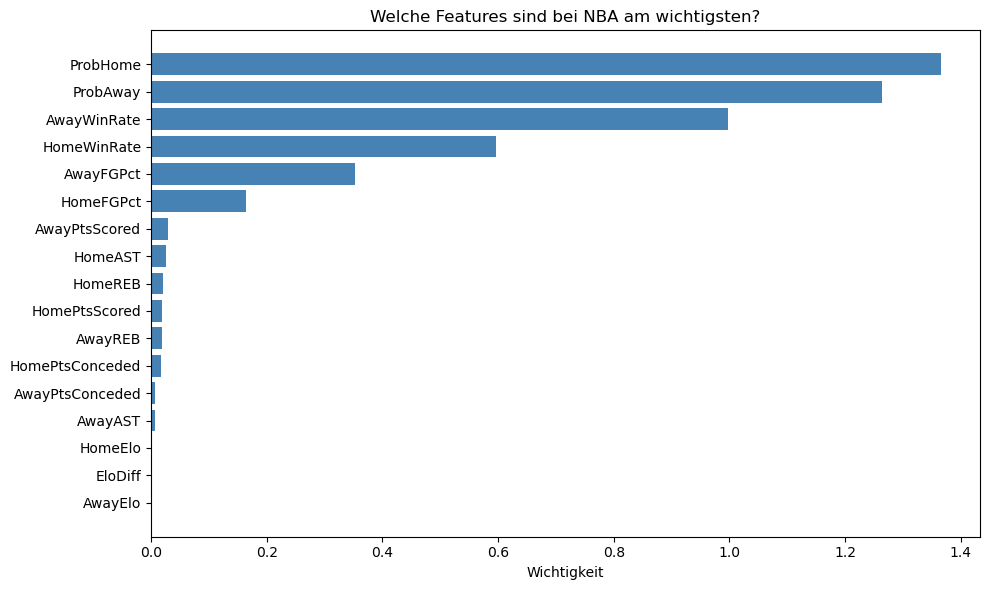

            Feature  Wichtigkeit
13          AwayElo     0.000238
14          EloDiff     0.000804
12          HomeElo     0.001042
9           AwayAST     0.006873
5   AwayPtsConceded     0.007083
3   HomePtsConceded     0.017965
11          AwayREB     0.018583
2     HomePtsScored     0.018723
10          HomeREB     0.021258
8           HomeAST     0.025492
4     AwayPtsScored     0.029485
6         HomeFGPct     0.164769
7         AwayFGPct     0.353205
0       HomeWinRate     0.596477
1       AwayWinRate     0.996899
16         ProbAway     1.263237
15         ProbHome     1.364849


In [21]:
# Feature Importance anzeigen
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    "Feature": features_nba_quotes,
    "Wichtigkeit": abs(modell_nba_quotes.coef_[0])
}).sort_values("Wichtigkeit", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance["Feature"], feature_importance["Wichtigkeit"], color="steelblue")
plt.xlabel("Wichtigkeit")
plt.title("Welche Features sind bei NBA am wichtigsten?")
plt.tight_layout()
plt.savefig("nba_feature_importance.png", dpi=150)
plt.show()

print(feature_importance.to_string())

In [22]:
# Nur die wichtigen Features
features_nba_optimal = [
    "HomeWinRate", "AwayWinRate",
    "HomeFGPct", "AwayFGPct",
    "ProbHome", "ProbAway"
]

X_train = daten_mit_quoten[features_nba_optimal].iloc[:split]
y_train = daten_mit_quoten["HOME_TEAM_WINS"].iloc[:split]
X_test = daten_mit_quoten[features_nba_optimal].iloc[split:]
y_test = daten_mit_quoten["HOME_TEAM_WINS"].iloc[split:]

modell_nba_optimal = LogisticRegression(max_iter=2000)
modell_nba_optimal.fit(X_train, y_train)

vorhersagen = modell_nba_optimal.predict(X_test)
genauigkeit = accuracy_score(y_test, vorhersagen)

print(f"NBA v3 (alle Features, kein Quoten): 63.2%")
print(f"NBA v4 (alle Features + Quoten):     61.5%")
print(f"NBA v5 (nur wichtige Features):      {genauigkeit:.1%}")

NBA v3 (alle Features, kein Quoten): 63.2%
NBA v4 (alle Features + Quoten):     61.5%
NBA v5 (nur wichtige Features):      61.5%


In [23]:
# Install the latest version
!pip install balldontlie

# Install a specific version
!pip install balldontlie==0.1.0

  Attempting uninstall: balldontlie
    Found existing installation: balldontlie 0.1.6
    Uninstalling balldontlie-0.1.6:
      Successfully uninstalled balldontlie-0.1.6


In [25]:
import requests
import pandas as pd

API_KEY = "98ee804c-c05f-4eb3-88cd-3b7d42ae474e"
headers = {"Authorization": API_KEY}

# Spiele der Saison 2024/25 laden (season=2024 = Saison 2024/25)
alle_spiele = []
cursor = None

while True:
    params = {
        "seasons[]": 2024,
        "per_page": 100,
        "postseason": "false"
    }
    if cursor:
        params["cursor"] = cursor
    
    response = requests.get(
        "https://api.balldontlie.io/v1/games",
        headers=headers,
        params=params
    )
    
    daten = response.json()
    spiele = daten["data"]
    alle_spiele.extend(spiele)
    
    # Nächste Seite?
    cursor = daten["meta"].get("next_cursor")
    if not cursor:
        break
    
    print(f"Geladen: {len(alle_spiele)} Spiele...")

print(f"\n✅ Saison 2024/25: {len(alle_spiele)} Spiele geladen")

Geladen: 100 Spiele...
Geladen: 200 Spiele...
Geladen: 300 Spiele...
Geladen: 400 Spiele...
Geladen: 500 Spiele...


JSONDecodeError: Expecting value: line 1 column 1 (char 0)

In [26]:
import requests
import pandas as pd

API_KEY = "98ee804c-c05f-4eb3-88cd-3b7d42ae474e"
# Fix: Properly format the Authorization header with "Bearer" prefix
headers = {"Authorization": f"Bearer {API_KEY}"}

# Spiele der Saison 2024/25 laden (season=2024 = Saison 2024/25)
alle_spiele = []
cursor = None

while True:
    params = {
        "seasons[]": 2024,
        "per_page": 100,
        "postseason": "false"
    }
    if cursor:
        params["cursor"] = cursor
    
    response = requests.get(
        "https://api.balldontlie.io/v1/games",
        headers=headers,
        params=params
    )
    
    # Add error handling to check response status
    if response.status_code != 200:
        print(f"Error: API returned status code {response.status_code}")
        print(f"Response content: {response.text}")
        break
    
    try:
        daten = response.json()
        spiele = daten["data"]
        alle_spiele.extend(spiele)
        
        # Nächste Seite?
        cursor = daten["meta"].get("next_cursor")
        if not cursor:
            break
        
        print(f"Geladen: {len(alle_spiele)} Spiele...")
    except ValueError as e:
        print(f"Error parsing JSON: {e}")
        print(f"Response content: {response.text}")
        break

print(f"\n✅ Saison 2024/25: {len(alle_spiele)} Spiele geladen")

Geladen: 100 Spiele...
Geladen: 200 Spiele...
Geladen: 300 Spiele...
Geladen: 400 Spiele...
Geladen: 500 Spiele...
Error: API returned status code 429
Response content: Too many requests, please try again later.

✅ Saison 2024/25: 500 Spiele geladen


In [27]:
import time

alle_spiele = []
cursor = None
seite = 0

while True:
    params = {
        "seasons[]": 2024,
        "per_page": 100,
        "postseason": "false"
    }
    if cursor:
        params["cursor"] = cursor
    
    response = requests.get(
        "https://api.balldontlie.io/v1/games",
        headers=headers,
        params=params
    )
    
    if response.status_code == 429:
        print("Rate limit erreicht – warte 30 Sekunden...")
        time.sleep(30)
        continue
    
    daten = response.json()
    spiele = daten["data"]
    alle_spiele.extend(spiele)
    seite += 1
    
    cursor = daten["meta"].get("next_cursor")
    if not cursor:
        break
    
    print(f"Geladen: {len(alle_spiele)} Spiele...")
    time.sleep(15)  # 15 Sekunden Pause zwischen Requests

print(f"\n✅ Saison 2024/25: {len(alle_spiele)} Spiele geladen")

Rate limit erreicht – warte 30 Sekunden...
Geladen: 100 Spiele...
Geladen: 200 Spiele...
Geladen: 300 Spiele...
Geladen: 400 Spiele...
Geladen: 500 Spiele...
Geladen: 600 Spiele...
Geladen: 700 Spiele...
Geladen: 800 Spiele...
Geladen: 900 Spiele...
Geladen: 1000 Spiele...
Geladen: 1100 Spiele...
Geladen: 1200 Spiele...

✅ Saison 2024/25: 1237 Spiele geladen


In [28]:
alle_spiele_2526 = []
cursor = None

while True:
    params = {
        "seasons[]": 2025,
        "per_page": 100,
        "postseason": "false"
    }
    if cursor:
        params["cursor"] = cursor
    
    response = requests.get(
        "https://api.balldontlie.io/v1/games",
        headers=headers,
        params=params
    )
    
    if response.status_code == 429:
        print("Rate limit – warte 30 Sekunden...")
        time.sleep(30)
        continue
    
    daten = response.json()
    spiele = daten["data"]
    alle_spiele_2526.extend(spiele)
    
    cursor = daten["meta"].get("next_cursor")
    if not cursor:
        break
    
    print(f"Geladen: {len(alle_spiele_2526)} Spiele...")
    time.sleep(15)

print(f"\n✅ Saison 2025/26: {len(alle_spiele_2526)} Spiele geladen")

Geladen: 100 Spiele...
Geladen: 200 Spiele...
Geladen: 300 Spiele...
Geladen: 400 Spiele...
Geladen: 500 Spiele...
Geladen: 600 Spiele...
Geladen: 700 Spiele...
Geladen: 800 Spiele...
Geladen: 900 Spiele...
Geladen: 1000 Spiele...
Geladen: 1100 Spiele...
Geladen: 1200 Spiele...

✅ Saison 2025/26: 1231 Spiele geladen


In [29]:
def spiele_zu_dataframe(spiele_liste):
    rows = []
    for spiel in spiele_liste:
        # Nur abgeschlossene Spiele
        if spiel["status"] != "Final":
            continue
        rows.append({
            "GAME_DATE_EST": spiel["date"],
            "HOME_TEAM_ID": spiel["home_team"]["id"],
            "VISITOR_TEAM_ID": spiel["visitor_team"]["id"],
            "PTS_home": spiel["home_team_score"],
            "PTS_away": spiel["visitor_team_score"],
            "SEASON": spiel["season"],
            "HOME_TEAM_WINS": 1 if spiel["home_team_score"] > spiel["visitor_team_score"] else 0
        })
    return pd.DataFrame(rows)

# Neue Saisons konvertieren
df_2425 = spiele_zu_dataframe(alle_spiele)
df_2526 = spiele_zu_dataframe(alle_spiele_2526)

print(f"Saison 2024/25: {len(df_2425)} abgeschlossene Spiele")
print(f"Saison 2025/26: {len(df_2526)} abgeschlossene Spiele")

# Mit alten Daten zusammenfügen
# Alte Daten haben andere Spaltennamen - angleichen
games_alt = games[games["SEASON"].isin([2022, 2023])][
    ["GAME_DATE_EST", "HOME_TEAM_ID", "VISITOR_TEAM_ID", 
     "PTS_home", "PTS_away", "SEASON", "HOME_TEAM_WINS"]
].copy()

# Alles zusammenfügen
daten_nba_komplett = pd.concat([games_alt, df_2425, df_2526], ignore_index=True)
daten_nba_komplett["GAME_DATE_EST"] = pd.to_datetime(daten_nba_komplett["GAME_DATE_EST"])
daten_nba_komplett = daten_nba_komplett.sort_values("GAME_DATE_EST").reset_index(drop=True)
daten_nba_komplett = daten_nba_komplett.dropna()

print(f"\nGesamt: {len(daten_nba_komplett)} Spiele")
print(f"Zeitraum: {daten_nba_komplett['GAME_DATE_EST'].min()} bis {daten_nba_komplett['GAME_DATE_EST'].max()}")

Saison 2024/25: 1237 abgeschlossene Spiele
Saison 2025/26: 1012 abgeschlossene Spiele

Gesamt: 2791 Spiele
Zeitraum: 2022-09-30 00:00:00 bis 2026-03-15 00:00:00


In [30]:
# Features berechnen
daten_nba_komplett["HomeWinRate"] = 0.0
daten_nba_komplett["AwayWinRate"] = 0.0
daten_nba_komplett["HomePtsScored"] = 0.0
daten_nba_komplett["HomePtsConceded"] = 0.0
daten_nba_komplett["AwayPtsScored"] = 0.0
daten_nba_komplett["AwayPtsConceded"] = 0.0

for i, row in daten_nba_komplett.iterrows():
    for team_id, prefix in [(row["HOME_TEAM_ID"], "Home"), (row["VISITOR_TEAM_ID"], "Away")]:
        vergangene = daten_nba_komplett[
            ((daten_nba_komplett["HOME_TEAM_ID"] == team_id) | 
             (daten_nba_komplett["VISITOR_TEAM_ID"] == team_id)) &
            (daten_nba_komplett["GAME_DATE_EST"] < row["GAME_DATE_EST"])
        ].tail(5)
        
        if len(vergangene) < 3:
            continue
        
        siege = 0
        pts_scored = []
        pts_conceded = []
        
        for _, spiel in vergangene.iterrows():
            if spiel["HOME_TEAM_ID"] == team_id:
                pts_scored.append(spiel["PTS_home"])
                pts_conceded.append(spiel["PTS_away"])
                if spiel["HOME_TEAM_WINS"] == 1:
                    siege += 1
            else:
                pts_scored.append(spiel["PTS_away"])
                pts_conceded.append(spiel["PTS_home"])
                if spiel["HOME_TEAM_WINS"] == 0:
                    siege += 1
        
        daten_nba_komplett.at[i, f"{prefix}WinRate"] = siege / len(vergangene)
        daten_nba_komplett.at[i, f"{prefix}PtsScored"] = sum(pts_scored) / len(pts_scored)
        daten_nba_komplett.at[i, f"{prefix}PtsConceded"] = sum(pts_conceded) / len(pts_conceded)

# Elo berechnen
daten_nba_komplett["HomeElo"] = 0.0
daten_nba_komplett["AwayElo"] = 0.0
daten_nba_komplett["EloDiff"] = 0.0
elo = {}

for i, row in daten_nba_komplett.iterrows():
    home = row["HOME_TEAM_ID"]
    away = row["VISITOR_TEAM_ID"]
    
    if home not in elo: elo[home] = 1500
    if away not in elo: elo[away] = 1500
    
    daten_nba_komplett.at[i, "HomeElo"] = elo[home]
    daten_nba_komplett.at[i, "AwayElo"] = elo[away]
    daten_nba_komplett.at[i, "EloDiff"] = elo[home] - elo[away]
    
    erwartung_home = 1 / (1 + 10 ** ((elo[away] - elo[home]) / 400))
    
    if row["HOME_TEAM_WINS"] == 1:
        ergebnis_home, ergebnis_away = 1, 0
    else:
        ergebnis_home, ergebnis_away = 0, 1
    
    elo[home] += 32 * (ergebnis_home - erwartung_home)
    elo[away] += 32 * (ergebnis_away - (1 - erwartung_home))

# Features entfernen ohne genug Historie
daten_nba_komplett = daten_nba_komplett[
    daten_nba_komplett["HomeWinRate"] > 0
].reset_index(drop=True)

print(f"Spiele mit Features: {len(daten_nba_komplett)}")

Spiele mit Features: 2513


In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

features_nba = [
    "HomeWinRate", "AwayWinRate",
    "HomePtsScored", "HomePtsConceded",
    "AwayPtsScored", "AwayPtsConceded",
    "HomeElo", "AwayElo", "EloDiff"
]

# Zeitbasierter Split – trainiere auf allem außer 25/26, teste auf 25/26
train = daten_nba_komplett[daten_nba_komplett["SEASON"] != 2025]
test = daten_nba_komplett[daten_nba_komplett["SEASON"] == 2025]

modell_nba_neu = LogisticRegression(max_iter=2000)
modell_nba_neu.fit(train[features_nba], train["HOME_TEAM_WINS"])

vorhersagen = modell_nba_neu.predict(test[features_nba])
genauigkeit = accuracy_score(test["HOME_TEAM_WINS"], vorhersagen)

print(f"Trainingsspiele: {len(train)}")
print(f"Testspiele (25/26): {len(test)}")
print(f"\n📊 Vergleich:")
print(f"Altes Modell (542 Spiele):  63.2%")
print(f"Neues Modell (2513 Spiele): {genauigkeit:.1%}")

Trainingsspiele: 1572
Testspiele (25/26): 941

📊 Vergleich:
Altes Modell (542 Spiele):  63.2%
Neues Modell (2513 Spiele): 64.9%


In [32]:
# Heutige Spiele abrufen
response = requests.get(
    "https://api.balldontlie.io/v1/games",
    headers=headers,
    params={"dates[]": "2026-03-16", "per_page": 100}
)

heute = response.json()["data"]
print(f"Spiele heute: {len(heute)}")
for spiel in heute:
    heim = spiel["home_team"]["full_name"]
    auswaerts = spiel["visitor_team"]["full_name"]
    status = spiel["status"]
    if status == "Final":
        print(f"  ✅ {heim} {spiel['home_team_score']} - {spiel['visitor_team_score']} {auswaerts}")
    else:
        print(f"  🕐 {heim} vs {auswaerts} ({status})")

Spiele heute: 8
  🕐 Atlanta Hawks vs Orlando Magic (2026-03-16T23:00:00Z)
  🕐 Washington Wizards vs Golden State Warriors (2026-03-16T23:00:00Z)
  🕐 Brooklyn Nets vs Portland Trail Blazers (2026-03-16T23:30:00Z)
  🕐 Boston Celtics vs Phoenix Suns (2026-03-16T23:30:00Z)
  🕐 Chicago Bulls vs Memphis Grizzlies (2026-03-17T00:00:00Z)
  🕐 New Orleans Pelicans vs Dallas Mavericks (2026-03-17T00:00:00Z)
  🕐 Houston Rockets vs Los Angeles Lakers (2026-03-17T01:30:00Z)
  🕐 LA Clippers vs San Antonio Spurs (2026-03-17T02:00:00Z)


In [33]:
# Team ID Mapping
team_id_map = {spiel["home_team"]["full_name"]: spiel["home_team"]["id"] for spiel in heute}
team_id_map.update({spiel["visitor_team"]["full_name"]: spiel["visitor_team"]["id"] for spiel in heute})

# Aktuelle Stats für jedes Team holen
def get_aktuelle_stats(team_id):
    vergangene = daten_nba_komplett[
        ((daten_nba_komplett["HOME_TEAM_ID"] == team_id) |
         (daten_nba_komplett["VISITOR_TEAM_ID"] == team_id))
    ].tail(5)
    
    if len(vergangene) < 3:
        return None
    
    siege = 0
    pts_scored = []
    pts_conceded = []
    
    for _, spiel in vergangene.iterrows():
        if spiel["HOME_TEAM_ID"] == team_id:
            pts_scored.append(spiel["PTS_home"])
            pts_conceded.append(spiel["PTS_away"])
            if spiel["HOME_TEAM_WINS"] == 1: siege += 1
        else:
            pts_scored.append(spiel["PTS_away"])
            pts_conceded.append(spiel["PTS_home"])
            if spiel["HOME_TEAM_WINS"] == 0: siege += 1
    
    return {
        "WinRate": siege / len(vergangene),
        "PtsScored": sum(pts_scored) / len(pts_scored),
        "PtsConceded": sum(pts_conceded) / len(pts_conceded),
        "Elo": elo.get(team_id, 1500)
    }

# Vorhersagen für alle Spiele
vorhersage_rows = []
for spiel in heute:
    heim_id = spiel["home_team"]["id"]
    auswaerts_id = spiel["visitor_team"]["id"]
    heim_name = spiel["home_team"]["full_name"]
    auswaerts_name = spiel["visitor_team"]["full_name"]
    
    heim_stats = get_aktuelle_stats(heim_id)
    auswaerts_stats = get_aktuelle_stats(auswaerts_id)
    
    if not heim_stats or not auswaerts_stats:
        print(f"⚠️ Nicht genug Daten für: {heim_name} vs {auswaerts_name}")
        continue
    
    vorhersage_rows.append({
        "HomeTeam": heim_name,
        "AwayTeam": auswaerts_name,
        "HomeWinRate": heim_stats["WinRate"],
        "AwayWinRate": auswaerts_stats["WinRate"],
        "HomePtsScored": heim_stats["PtsScored"],
        "HomePtsConceded": heim_stats["PtsConceded"],
        "AwayPtsScored": auswaerts_stats["PtsScored"],
        "AwayPtsConceded": auswaerts_stats["PtsConceded"],
        "HomeElo": heim_stats["Elo"],
        "AwayElo": auswaerts_stats["Elo"],
        "EloDiff": heim_stats["Elo"] - auswaerts_stats["Elo"]
    })

heute_df = pd.DataFrame(vorhersage_rows)

# Vorhersagen
vorhersagen = modell_nba_neu.predict(heute_df[features_nba])
wahrscheinlichkeiten = modell_nba_neu.predict_proba(heute_df[features_nba])

# Ausgabe
print("🏀 NBA Vorhersagen – Heute 16. März 2026")
print("=" * 60)

for idx, row in heute_df.iterrows():
    prob_home = wahrscheinlichkeiten[idx][1]
    prob_away = wahrscheinlichkeiten[idx][0]
    tipp = row["HomeTeam"] if vorhersagen[idx] == 1 else row["AwayTeam"]
    
    print(f"\n{row['HomeTeam']} vs {row['AwayTeam']}")
    print(f"  Tipp:  🏆 {tipp}")
    print(f"  Heim:  {prob_home:.0%} | Auswärts: {prob_away:.0%}")
    print(f"  Elo:   {row['HomeElo']:.0f} vs {row['AwayElo']:.0f}")

print(f"\n{'='*60}")

🏀 NBA Vorhersagen – Heute 16. März 2026

Atlanta Hawks vs Orlando Magic
  Tipp:  🏆 Atlanta Hawks
  Heim:  55% | Auswärts: 45%
  Elo:   1562 vs 1594

Washington Wizards vs Golden State Warriors
  Tipp:  🏆 Golden State Warriors
  Heim:  27% | Auswärts: 73%
  Elo:   1271 vs 1438

Brooklyn Nets vs Portland Trail Blazers
  Tipp:  🏆 Portland Trail Blazers
  Heim:  24% | Auswärts: 76%
  Elo:   1293 vs 1473

Boston Celtics vs Phoenix Suns
  Tipp:  🏆 Boston Celtics
  Heim:  70% | Auswärts: 30%
  Elo:   1643 vs 1554

Chicago Bulls vs Memphis Grizzlies
  Tipp:  🏆 Chicago Bulls
  Heim:  60% | Auswärts: 40%
  Elo:   1381 vs 1305

New Orleans Pelicans vs Dallas Mavericks
  Tipp:  🏆 New Orleans Pelicans
  Heim:  72% | Auswärts: 28%
  Elo:   1417 vs 1360

Houston Rockets vs Los Angeles Lakers
  Tipp:  🏆 Houston Rockets
  Heim:  53% | Auswärts: 47%
  Elo:   1581 vs 1610

LA Clippers vs San Antonio Spurs
  Tipp:  🏆 San Antonio Spurs
  Heim:  44% | Auswärts: 56%
  Elo:   1582 vs 1723



In [34]:
# Excel Datei mit Vorhersagen erstellen
!pip install openpyxl

import openpyxl
from openpyxl.styles import PatternFill, Font, Alignment, Border, Side
from openpyxl.utils import get_column_letter

# Workbook erstellen
wb = openpyxl.Workbook()
ws = wb.active
ws.title = "NBA Predictions"

# Farben definieren
gruen = PatternFill(start_color="90EE90", end_color="90EE90", fill_type="solid")
rot = PatternFill(start_color="FFB6C1", end_color="FFB6C1", fill_type="solid")
blau = PatternFill(start_color="ADD8E6", end_color="ADD8E6", fill_type="solid")
grau = PatternFill(start_color="D3D3D3", end_color="D3D3D3", fill_type="solid")
fett = Font(bold=True)

# Header
headers = ["Datum", "Heimteam", "Auswärtsteam", "Tipp", 
           "Heim %", "Auswärts %", "Elo Heim", "Elo Auswärts",
           "Echtes Ergebnis", "Richtig?"]

for col, header in enumerate(headers, 1):
    zelle = ws.cell(row=1, column=col, value=header)
    zelle.font = fett
    zelle.fill = grau
    zelle.alignment = Alignment(horizontal="center")

# Spaltenbreiten
breiten = [12, 25, 25, 25, 10, 12, 12, 12, 20, 10]
for col, breite in enumerate(breiten, 1):
    ws.column_dimensions[get_column_letter(col)].width = breite

# Daten einfügen
for idx, row in heute_df.iterrows():
    prob_home = wahrscheinlichkeiten[idx][1]
    prob_away = wahrscheinlichkeiten[idx][0]
    tipp = row["HomeTeam"] if vorhersagen[idx] == 1 else row["AwayTeam"]
    
    zeile = idx + 2
    daten = [
        "16.03.2026",
        row["HomeTeam"],
        row["AwayTeam"],
        tipp,
        f"{prob_home:.0%}",
        f"{prob_away:.0%}",
        f"{row['HomeElo']:.0f}",
        f"{row['AwayElo']:.0f}",
        "",  # Echtes Ergebnis – später ausfüllen
        ""   # Richtig? – später ausfüllen
    ]
    
    for col, wert in enumerate(daten, 1):
        zelle = ws.cell(row=zeile, column=col, value=wert)
        zelle.alignment = Alignment(horizontal="center")
        
        # Tipp Spalte blau einfärben
        if col == 4:
            zelle.fill = blau

# Hinweis Zeile
ws.cell(row=len(heute_df) + 3, column=1, 
        value="→ Trage das echte Ergebnis in Spalte I ein (z.B. 'Atlanta Hawks')")
ws.cell(row=len(heute_df) + 4, column=1,
        value="→ Trage in Spalte J 'Richtig' oder 'Falsch' ein – Zellen werden grün/rot")

# Datei speichern
wb.save(os.path.expanduser("~/Downloads/nba_predictions.xlsx"))
print("✅ Excel Datei gespeichert: ~/Downloads/nba_predictions.xlsx")

✅ Excel Datei gespeichert: ~/Downloads/nba_predictions.xlsx
